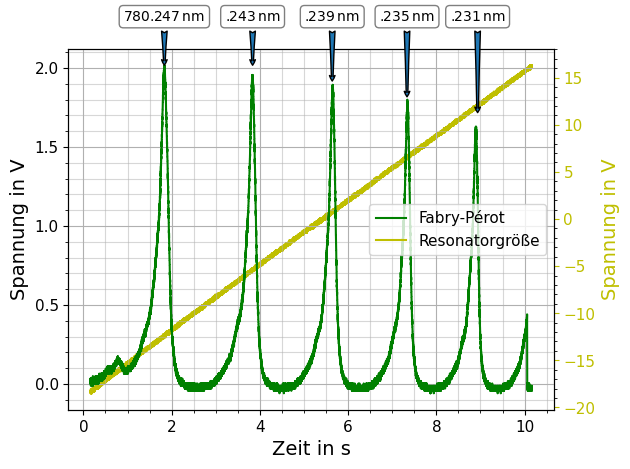

In [1]:
# Modensuche und FP Kalibration (eig. Darstellung der gefundenen Moden)
import numpy as np
import matplotlib.pyplot as plt

t, piezo = np.loadtxt(r'../Messdaten/20260518_Laserspektroskopie/scope_1_1.csv', skiprows=2, unpack=True, delimiter=',')
_, FPI = np.loadtxt(r'../Messdaten/20260518_Laserspektroskopie/scope_1_2.csv', skiprows=2, unpack=True, delimiter=',')
_, Rb = np.loadtxt(r'../Messdaten/20260518_Laserspektroskopie/scope_1_3.csv', skiprows=2, unpack=True, delimiter=',')

FP_Kalib = [#(Zeit, Höhe), Wellenlänge
            [(1.835, 2), "780.247"],
            [(3.835, 2), ".243"],
            [(5.640, 2), ".239"],
            [(7.335, 2), ".235"],
            [(8.935, 2), ".231"]]

offsets = [(0, 0), (0, 0), (0, -0.1), (0, -0.2), (0, -0.3)]

def xyshift(xy, xoff=0.0, yoff=0.0):
    x, y = xy[0] + xoff, xy[1] + yoff
    return (x,y)



modefig, modeax = plt.subplots()
modeax2 = modeax.twinx()
modeax2.plot(t, piezo, "y", label="Resonatorgröße")
modeax.plot(t, FPI, "g", label="Fabry-Pérot")
#modeax.plot(t, Rb, "b", label="Transmission")

for (peak, wellenlänge), (xoff, yoff) in zip(FP_Kalib, offsets):
    modeax.annotate(text=wellenlänge+r"$\,$nm", xy=xyshift(peak, xoff, yoff), xytext=xyshift(peak, 0, 0.3), arrowprops={'arrowstyle': 'fancy'}, ha='center', bbox={'boxstyle':'round', 'alpha':0.5, 'fc':'white', 'ec':'black'})

modeax.set_xlabel("Zeit in s", fontsize=14)
modeax.set_ylabel("Spannung in V", fontsize=14)
modeax2.set_ylabel("Spannung in V", fontsize=14, color="y")
modeax.tick_params(labelsize=11)
modeax2.tick_params(axis="y", colors="y", labelsize=11)

modeax.minorticks_on()
modeax2.minorticks_on()
modeax.grid(which="major")
modeax.grid(which="minor", alpha=0.5)

handles1, labels1 = modeax.get_legend_handles_labels()
handles2, labels2 = modeax2.get_legend_handles_labels()
modeax.legend(handles1+handles2, labels1+labels2, fontsize=11, loc="center right")

modefig.tight_layout()
modeax.set_zorder(10)
modeax.patch.set_visible(False)
#modefig.savefig("../Bilder/Laserspektroskopie/Modensuche.pdf")

l= (-6.542397e-04 +/- 1.807450e-05)nm/V * U + (7.802391570e+02 +/- 1.561620e-04)nm


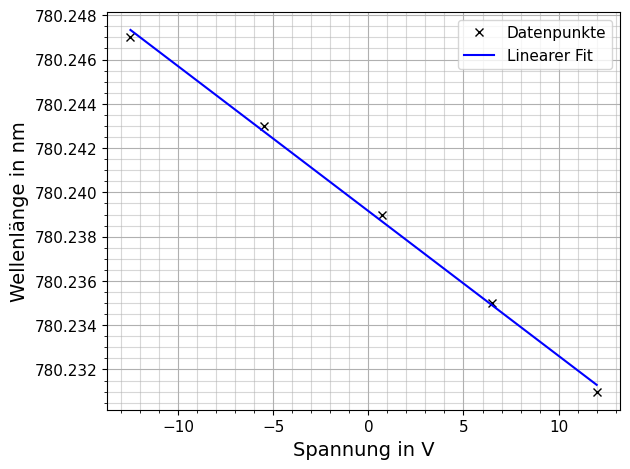

In [2]:
# Piezo Calibration
from scipy.stats import linregress
U, wl = np.array([[-12.5, -5.5, 0.7, 6.5, 12],[780.247, 780.243, 780.239, 780.235, 780.231]])

piezofit = linregress(U, wl)

def V_to_nm(V):
    return piezofit.slope * V + piezofit.intercept

print(f"l= ({piezofit.slope:e} +/- {piezofit.stderr:e})nm/V * U + ({piezofit.intercept:.9e} +/- {piezofit.intercept_stderr:e})nm")

fitfig, fitax = plt.subplots()
fitax.plot(U, wl, "xk",label="Datenpunkte")
fitax.plot(U, piezofit.intercept+piezofit.slope*U, "b", label="Linearer Fit")

fitax.set_xlabel("Spannung in V", fontsize=14)
fitax.set_ylabel("Wellenlänge in nm", fontsize=14)

fitax.ticklabel_format(useOffset=False)

fitax.legend(fontsize=11)
fitax.tick_params(labelsize=11)

fitax.minorticks_on()
fitax.grid(which="major")
fitax.grid(which="minor", alpha=0.5)
fitfig.tight_layout()
#fitfig.savefig("../Bilder/Laserspektroskopie/FPI Kalibration.pdf")

C:\Users\nicol\AppData\Local\Temp\ipykernel_14000\4222284805.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  doppfig.show()


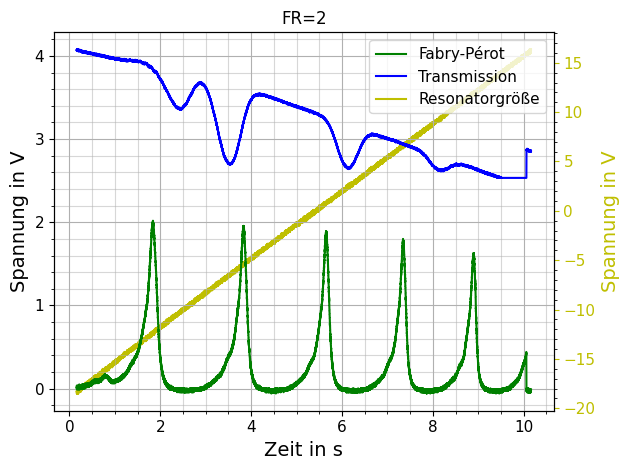

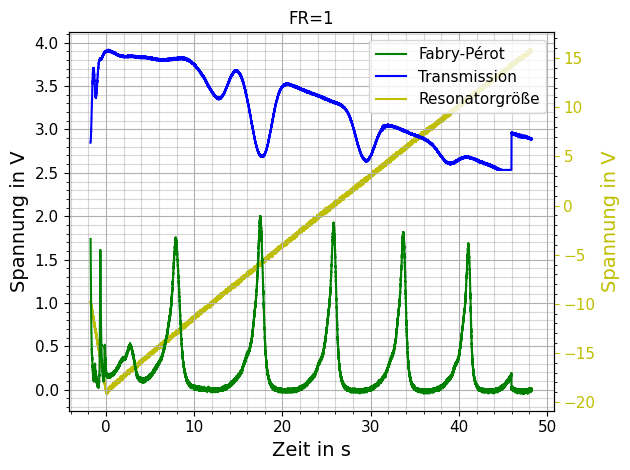

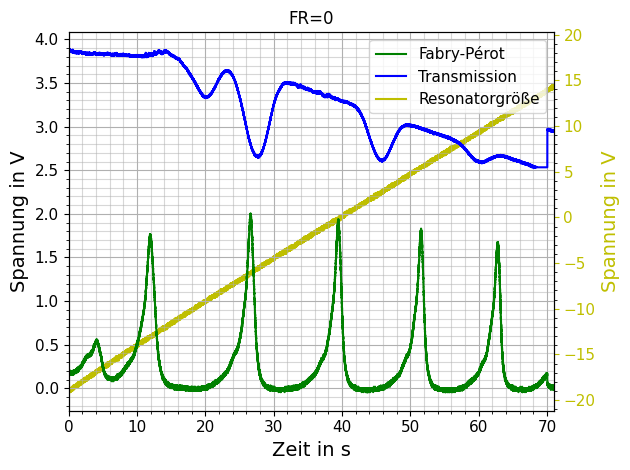

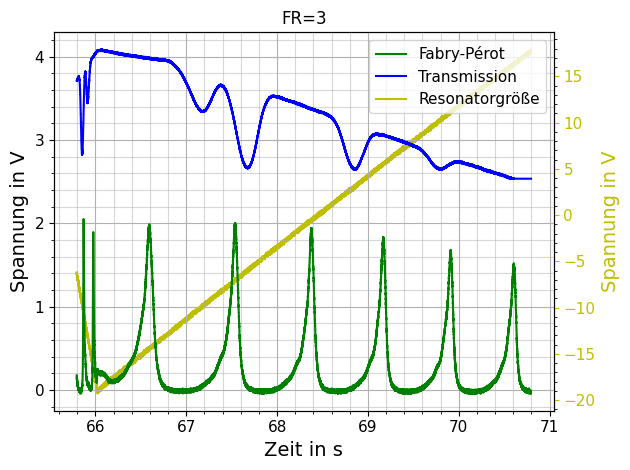

In [3]:
import numpy as np
import matplotlib.pyplot as plt

for i, FR in enumerate(["FR=2", "FR=1", "FR=0", "FR=3"]):
    i += 1 # weil 0 indiziert
    t, piezo = np.loadtxt(r"../Messdaten/20260518_Laserspektroskopie/scope_"+str(i)+r"_1.csv", skiprows=2, unpack=True, delimiter=',')
    _, FPI = np.loadtxt(r"../Messdaten/20260518_Laserspektroskopie/scope_"+str(i)+r"_2.csv", skiprows=2, unpack=True, delimiter=',')
    _, Rb = np.loadtxt(r"../Messdaten/20260518_Laserspektroskopie/scope_"+str(i)+r"_3.csv", skiprows=2, unpack=True, delimiter=',')



    doppfig, doppax = plt.subplots()
    doppax2 = doppax.twinx()
    doppax2.plot(t, piezo, "y", label="Resonatorgröße")
    doppax.plot(t, FPI, "g", label="Fabry-Pérot")
    doppax.plot(t, Rb, "b", label="Transmission")

    doppax.set_title(FR)

    if i == 3:
        doppax.set_xlim(0,71)

    doppax.set_xlabel("Zeit in s", fontsize=14)
    doppax.set_ylabel("Spannung in V", fontsize=14)
    doppax2.set_ylabel("Spannung in V", fontsize=14, color="y")
    doppax.tick_params(labelsize=11)
    doppax2.tick_params(axis="y", colors="y", labelsize=11)

    doppax.minorticks_on()
    doppax2.minorticks_on()
    doppax.grid(which="major")
    doppax.grid(which="minor", alpha=0.5)

    handles1, labels1 = doppax.get_legend_handles_labels()
    handles2, labels2 = doppax2.get_legend_handles_labels()
    doppax.legend(handles1+handles2, labels1+labels2, fontsize=11, loc="upper right")

    doppfig.tight_layout()
    doppax.set_zorder(10)
    doppax.patch.set_visible(False)
    doppfig.show()
    FR_tit = FR.split("=")[-1]
    #doppfig.savefig(f"../Bilder/Laserspektroskopie/Dopplermessung_FR_{FR_tit}.pdf")

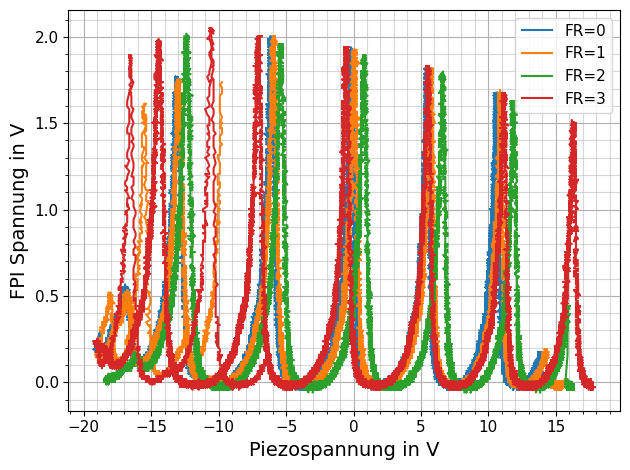

In [ ]:
# Plot FPI vs. Piezo
fpifig, fpiax = plt.subplots()
for i, FR in zip([3, 2, 1, 4], ["FR=0", "FR=1", "FR=2", "FR=3"]):
    t, piezo = np.loadtxt(r"../Messdaten/20260518_Laserspektroskopie/scope_"+str(i)+r"_1.csv", skiprows=2, unpack=True, delimiter=',')
    _, FPI = np.loadtxt(r"../Messdaten/20260518_Laserspektroskopie/scope_"+str(i)+r"_2.csv", skiprows=2, unpack=True, delimiter=',')
    _, Rb = np.loadtxt(r"../Messdaten/20260518_Laserspektroskopie/scope_"+str(i)+r"_3.csv", skiprows=2, unpack=True, delimiter=',')

    if i == 3:
        #get index where 0<=t<=71 and mask FR=3
        m1 = t >= 0
        m2 = t <= 71
        m = m1 * m2
        fpiax.plot(piezo[m], FPI[m], label=FR)
    else:
        fpiax.plot(piezo, FPI, label=FR)

fpiax.set_xlabel("Piezospannung in V", fontsize=14)
fpiax.set_ylabel("FPI Spannung in V", fontsize=14)

fpiax.tick_params(labelsize=11)

fpiax.ticklabel_format(useOffset=False)

fpiax.minorticks_on()
fpiax.grid(which="major")
fpiax.grid(which="minor", alpha=0.5)


fpiax.legend(fontsize=11)
fpifig.tight_layout()
#fpifig.savefig("../Bilder/Laserspektroskopie/Hysteresen.pdf")

In [5]:
# Abgelesene Piezospannungen
nm = [780.247, 780.243, 780.239, 780.235, 780.231]
FR2 = [-12.5, -5.5, 0.7, 6.5, 12]
FR1 = [-13, -6, 0, 6, 11]
FR0 = [-13, -6, 0, 5, 10.5]
FR3 = [-14, -7, -0.5, 5, 11]

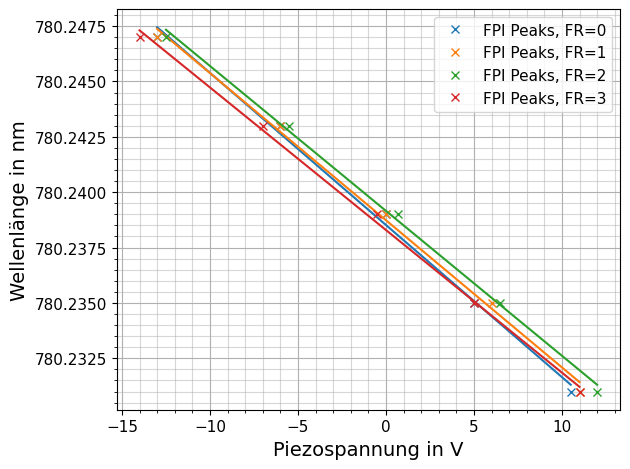

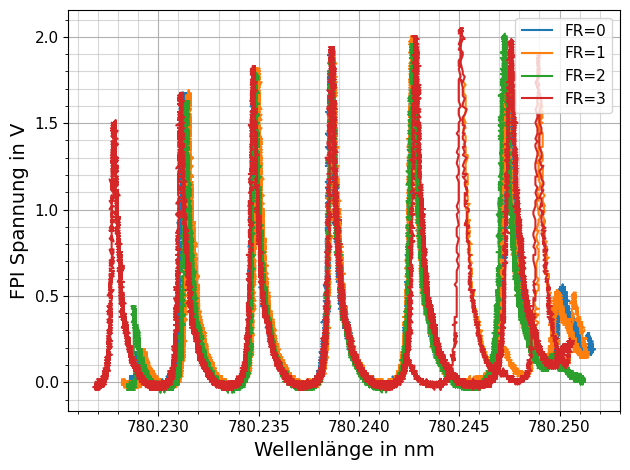

In [ ]:
# Plot Vpiezo vs Wavelength for all frequencies
from scipy.stats import linregress

def V_to_nm(V, slope, intercept):
    return slope * V + intercept

dic = {"FR=0":"3", "FR=1":"2", "FR=2":"1", "FR=3":"4"}

hysfig, hysax = plt.subplots()
corrfig, corrax = plt.subplots()

for FR, lab, col in zip([FR0, FR1, FR2, FR3], ["FR=0", "FR=1", "FR=2", "FR=3"], ["tab:blue", "tab:orange", "tab:green", "tab:red"]):
    fit = linregress(FR, nm)
    slope, intercept = fit.slope, fit.intercept
    hysax.plot(FR, V_to_nm(np.array(FR), slope, intercept), col)
    hysax.plot(FR, nm, "x", color=col, label="FPI Peaks, "+lab)

    t, piezo = np.loadtxt(r"../Messdaten/20260518_Laserspektroskopie/scope_"+dic[lab]+r"_1.csv", skiprows=2, unpack=True, delimiter=',')
    _, FPI = np.loadtxt(r"../Messdaten/20260518_Laserspektroskopie/scope_"+dic[lab]+r"_2.csv", skiprows=2, unpack=True, delimiter=',')
    if lab == "FR=0":
        m1 = t >= 0
        m2 = t <= 71
        m = m1 * m2
        corrax.plot(V_to_nm(piezo[m], slope, intercept), FPI[m], label=lab)
    else:
        corrax.plot(V_to_nm(piezo, slope, intercept), FPI, label=lab)

for fig, ax in [(hysfig, hysax), (corrfig, corrax)]:
    ax.set_ylabel("Wellenlänge in nm", fontsize=14)
    ax.set_xlabel("Spannung in V", fontsize=14)
    ax.tick_params(labelsize=11)

    ax.ticklabel_format(useOffset=False)

    ax.minorticks_on()
    ax.grid(which="major")
    ax.grid(which="minor", alpha=0.5)


    ax.legend(fontsize=11, loc="upper right")
    fig.tight_layout()
hysax.set_ylabel("Wellenlänge in nm", fontsize=14)
hysax.set_xlabel("Piezospannung in V", fontsize=14)
corrax.set_xlabel("Wellenlänge in nm", fontsize=14)
corrax.set_ylabel("FPI Spannung in V", fontsize=14)
#hysfig.savefig("../Bilder/Laserspektroskopie/Vier Fits nm vs Vpiezo.pdf")
#corrfig.savefig("../Bilder/Laserspektroskopie/Korrigierte Hysteresen.pdf")

In [7]:
# Berechnung der theoretischen Wellenlängen der Übergänge aus den Frequenzen
import scipy.constants as const
c = const.c

def lambda_err(lam, f0, f0_err, df, df_err):
    return lam / (f0-df) * (f0_err + df_err)

Rb85_f0 = 384.230406373e3 #GHz
Rb85_f1 = 1.264888516 #GHz
Rb85_f2 = -1.7708439228 #GHz

Rb87_f0 = 384.2304844685e3 #GHz
Rb87_f1 = 2.563005979089109 #GHz
Rb87_f2 = -4.271676631815181 #GHz

f0s = [Rb85_f0, Rb85_f0, Rb87_f0, Rb87_f0]
dfs = [Rb85_f1, Rb85_f2, Rb87_f1, Rb87_f2]

f0_errs = (0.000014, 0.000014, 0.0000062, 0.0000062) #GHz
df_errs = (0.0000000025, 0.0000000035, 0.000000000000034, 0.000000000000056)

new_lambda = [c/(Rb85_f0 - Rb85_f1), c/(Rb85_f0 - Rb85_f2), c/(Rb87_f0 - Rb87_f1), c/(Rb87_f0 - Rb87_f2)]
new_lambda_err = []
for lam, f0, f0_err, df, df_err in zip(new_lambda, f0s, f0_errs, dfs, df_errs):
    new_lambda_err.append(lambda_err(lam, f0, f0_err, df, df_err))

print(new_lambda)
print(new_lambda_err)

[780.24393683868, 780.2377723059582, 780.2464143128207, 780.232535462678]
[2.843450573106727e-08, 2.843608706492598e-08, 1.2590255744180053e-08, 1.25898078874844e-08]


Abgelesene Amplitudentiefen v.l.n.r.
780.2330nm: Gerade bei 2.802 V und Peak bei 2.62 V => 0.1823 V Tiefe
780.2375nm: Gerade bei 3.181 V und Peak bei 2.65 V => 0.5307 V Tiefe
780.2445nm: Gerade bei 3.769 V und Peak bei 2.70 V => 1.069 V Tiefe
780.2460nm: Gerade bei 3.895 V und Peak bei 3.35 V => 0.5455 V Tiefe


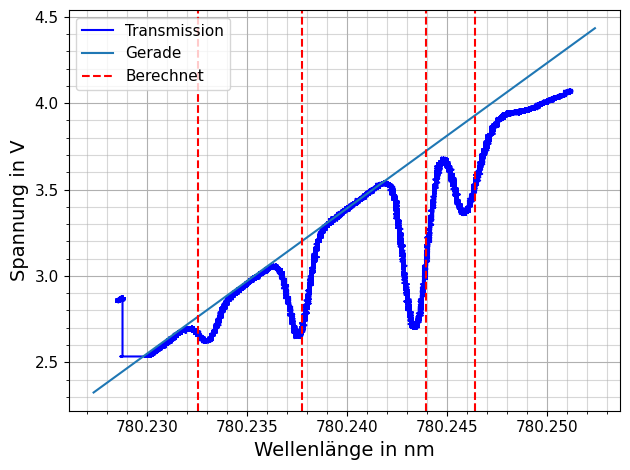

In [8]:
# Analyse der Peaks
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

t, piezo = np.loadtxt(r'../Messdaten/20260518_Laserspektroskopie/scope_1_1.csv', skiprows=2, unpack=True, delimiter=',')
_, FPI = np.loadtxt(r'../Messdaten/20260518_Laserspektroskopie/scope_1_2.csv', skiprows=2, unpack=True, delimiter=',')
_, Rb = np.loadtxt(r'../Messdaten/20260518_Laserspektroskopie/scope_1_3.csv', skiprows=2, unpack=True, delimiter=',')

V = V_to_nm(piezo, -6.542397e-04, 7.802391570e+02)

gerade = linregress([780.23, 780.241], [2.55, 3.475])

fig, ax = plt.subplots()
ax.plot(V, Rb, "b", label="Transmission")
x = np.array(ax.get_xlim())
ax.plot(x, gerade.slope * x + gerade.intercept)
#ax.plot(V, FPI, "g", label="Fabry-Pérot")

for Übergang in new_lambda:
    ax.axvline(Übergang, color="r", ls="--")

ax.set_xlabel("Wellenlänge in nm", fontsize=14)
ax.set_ylabel("Spannung in V", fontsize=14)
ax.tick_params(labelsize=11)

ax.ticklabel_format(useOffset=False)

ax.minorticks_on()
ax.grid(which="major")
ax.grid(which="minor", alpha=0.5)

ax.legend(["Transmission", "Gerade", "Berechnet"], fontsize=11)

fig.tight_layout()
#fig.savefig("../Bilder/Laserspektroskopie/Übergänge mit Theorie.pdf")

print("Abgelesene Amplitudentiefen v.l.n.r.")
print(f"780.2330nm: Gerade bei {780.233*gerade.slope+gerade.intercept:.4} V und Peak bei 2.62 V => {780.233*gerade.slope+gerade.intercept-2.62:.4} V Tiefe")
print(f"780.2375nm: Gerade bei {780.2375*gerade.slope+gerade.intercept:.4} V und Peak bei 2.65 V => {780.2375*gerade.slope+gerade.intercept-2.65:.4} V Tiefe")
print(f"780.2445nm: Gerade bei {780.2445*gerade.slope+gerade.intercept:.4} V und Peak bei 2.70 V => {780.2445*gerade.slope+gerade.intercept-2.7:.4} V Tiefe")
print(f"780.2460nm: Gerade bei {780.246*gerade.slope+gerade.intercept:.4} V und Peak bei 3.35 V => {780.246*gerade.slope+gerade.intercept-3.35:.4} V Tiefe")

### Isotopenverhältnis:
$^{85}Rb: \ ^{87}Rb$  
72:28  

### Abgelesene Übergänge v.l.n.r.
(780.2330 $\pm$ 0.0005) nm sollte 85  
(780.2375 $\pm$ 0.0005) nm sollte 87  
(780.2435 $\pm$ 0.0005) nm sollte 87  
(780.2460 $\pm$ 0.0005) nm sollte 85

### Berechnete Übergänge mit Hyperfeinstruktur:
$^{85}Rb$:  
(780.243936837 $\pm$ 0.000000029) nm  
(780.237772306 $\pm$ 0.000000029) nm  
  
$^{87}Rb$:  
(780.246414313 $\pm$ 0.000000013) nm  
(780.232535463 $\pm$ 0.000000013) nm